In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

[16:54:35] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=447237;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=441728;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

# **Fractal Dimension** 

In [2]:
import numpy as np
from skimage.measure import perimeter, label, regionprops

def euler_number(mask):
    labeled = label(mask)
    regions = regionprops(labeled)
    return sum([r.euler_number for r in regions])

def standard_minkowski_functionals2(data, threshold_min=1e20, threshold_max=1e22, thresholds=None,
                                    num_samples=10, intensity_noise_std=1.0):
    """
    Compute the standard Minkowski functionals (area, perimeter, Euler characteristic)
    and fractal dimension with uncertainty using Monte Carlo sampling.

    Parameters:
    ----------
    data : numpy.ndarray
        2D array representing the dataset.
    threshold_min : float
        Minimum threshold if thresholds are auto-generated.
    threshold_max : float
        Maximum threshold if thresholds are auto-generated.
    thresholds : numpy.ndarray or None
        Array of threshold values. If None, generated logarithmically.
    num_samples : int
        Number of Monte Carlo samples per threshold.
    intensity_noise_std : float
        Standard deviation of noise added to data in each sample.

    Returns:
    -------
    dict
        Dictionary with computed values and uncertainties:
        - "thresholds"
        - "areas", "area_unc"
        - "perimeters", "perimeter_unc"
        - "euler_chars", "euler_unc"
        - "fractal_dimension", "sigma_D"
    """
    if thresholds is None:
        thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100)

    areas = []
    area_unc = []
    perimeters = []
    perimeter_unc = []
    euler_chars = []
    euler_unc = []

    for threshold in thresholds:
        area_samples = []
        perim_samples = []
        euler_samples = []

        for _ in range(num_samples):
            noisy_data = data + np.random.normal(0, intensity_noise_std, size=data.shape)
            mask = noisy_data >= threshold

            area_samples.append(np.sum(mask))
            perim_samples.append(perimeter(mask))
            euler_samples.append(euler_number(mask))

        areas.append(np.mean(area_samples))
        area_unc.append(np.std(area_samples))

        perimeters.append(np.mean(perim_samples))
        perimeter_unc.append(np.std(perim_samples))

        euler_chars.append(np.mean(euler_samples))
        euler_unc.append(np.std(euler_samples))

    # Convert to arrays
    areas = np.array(areas)
    area_unc = np.array(area_unc)
    perimeters = np.array(perimeters)
    perimeter_unc = np.array(perimeter_unc)
    euler_chars = np.array(euler_chars)
    euler_unc = np.array(euler_unc)

    # Log scale for fractal dimension
    log_areas = np.log10(areas)
    log_perimeters = np.log10(perimeters)

    valid = np.isfinite(log_areas) & np.isfinite(log_perimeters)
    slope, intercept = np.polyfit(log_perimeters[valid], log_areas[valid], 1)
    D = (2 * log_perimeters) / log_areas

    # Propagate uncertainty to fractal dimension
    dD_dP = 2 / (np.log(10) * perimeters * log_areas)
    dD_dA = -2 * log_perimeters / (np.log(10) * areas * log_areas**2)
    sigma_D = np.sqrt((dD_dP * perimeter_unc)**2 + (dD_dA * area_unc)**2)

    return {
        "thresholds": thresholds,
        "areas": areas,
        "area_unc": area_unc,
        "perimeters": perimeters,
        "perimeter_unc": perimeter_unc,
        "euler_chars": euler_chars,
        "euler_unc": euler_unc,
        "fractal_dimension": D,
        "sigma_D": sigma_D
    }


2.972512859016305
Correlation coefficient: 0.9893
Slope uncertainty (standard error): 0.0221
Fractal dimension D = 1.35 ± 0.02


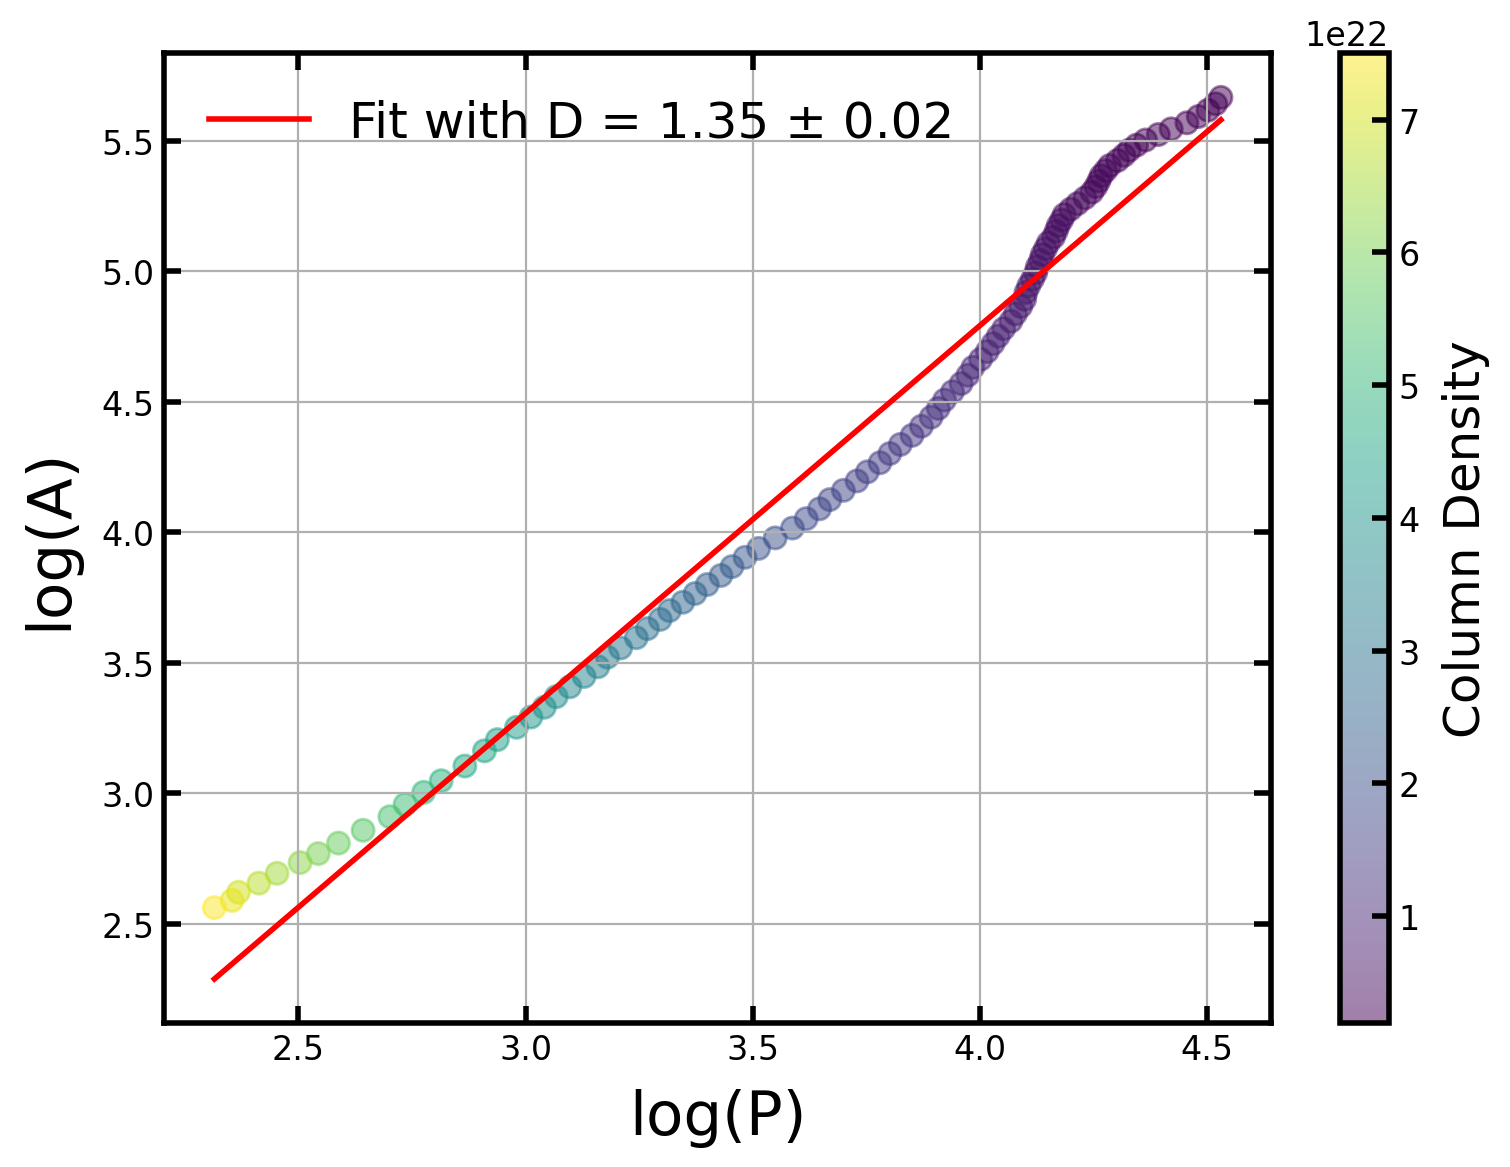

In [ ]:
from scipy.stats import linregress

# global fractal dimension (Orion A)

# Orion A
region_name = "Orion A"

# range Orion A (whole)
threshold_min = 1.95e21
threshold_max = 7.5e22

# threshold_max = 1.0e23

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

log_perimeters = np.log10(np.array(results_OA["perimeters"]))
log_areas = np.log10(np.array(results_OA["areas"]))

sigma_A = np.sqrt(np.array(results_OA["areas"]))  # rough Poisson error
sigma_P = 0.5 * np.sqrt(np.array(results_OA["perimeters"]))  # rough guess; adjust based on your system

# Perform linear regression
coefficients = np.polyfit(log_perimeters, log_areas, 1)
slope, intercept = coefficients

# Calculate correlation coefficient between log_perimeters and log_areas
corr_coef = np.corrcoef(log_perimeters, log_areas)[0, 1]
print(f"Correlation coefficient: {corr_coef:.4f}")

# Estimate fit uncertainty (standard error of the slope)
reg = linregress(log_perimeters, log_areas)
slope_err = reg.stderr
print(f"Slope uncertainty (standard error): {slope_err:.4f}")
print(f"Fractal dimension D = {2/slope:.2f} ± {2 * slope_err / slope**2:.2f}")

plt.figure(figsize=(8, 6))
# Normalize thresholds for color mapping
thresholds = results_OA["thresholds"]
norm = plt.Normalize(threshold_min, threshold_max)
cmap = plt.cm.viridis

# Scatter plot with color gradient based on thresholds
sc = plt.scatter(
    log_perimeters, log_areas,
    c=thresholds, cmap=cmap, norm=norm, alpha = 0.5
)
cbar = plt.colorbar(sc)
cbar.set_label("Column Density", fontsize=18)
plt.plot(
    log_perimeters,
    slope * log_perimeters + intercept,
    label=f"Fit with D = {2/slope:.2f} ± {2 * slope_err / slope**2:.2f}",
    color="red"
)

# plt.errorbar(
#     log_perimeters, log_areas,
#     xerr=sigma_P / (np.array(results_OA["perimeters"]) * np.log(10)),
#     yerr=sigma_A / (np.array(results_OA["areas"]) * np.log(10)),
#     fmt='none', ecolor='gray', alpha=0.5, capsize=2, label='Uncertainty'
# )

plt.xlabel("log(P)", fontsize=22)
plt.ylabel("log(A)", fontsize=22)
# plt.title("Log-Log Plot of Areas vs Perimeters with Linear Fit")
plt.legend(fontsize=18)
plt.grid(True)
plt.show()

2.859715631165698
Correlation coefficient: 0.9976
Slope uncertainty (standard error): 0.0101
Fractal dimension D = 1.40 ± 0.01


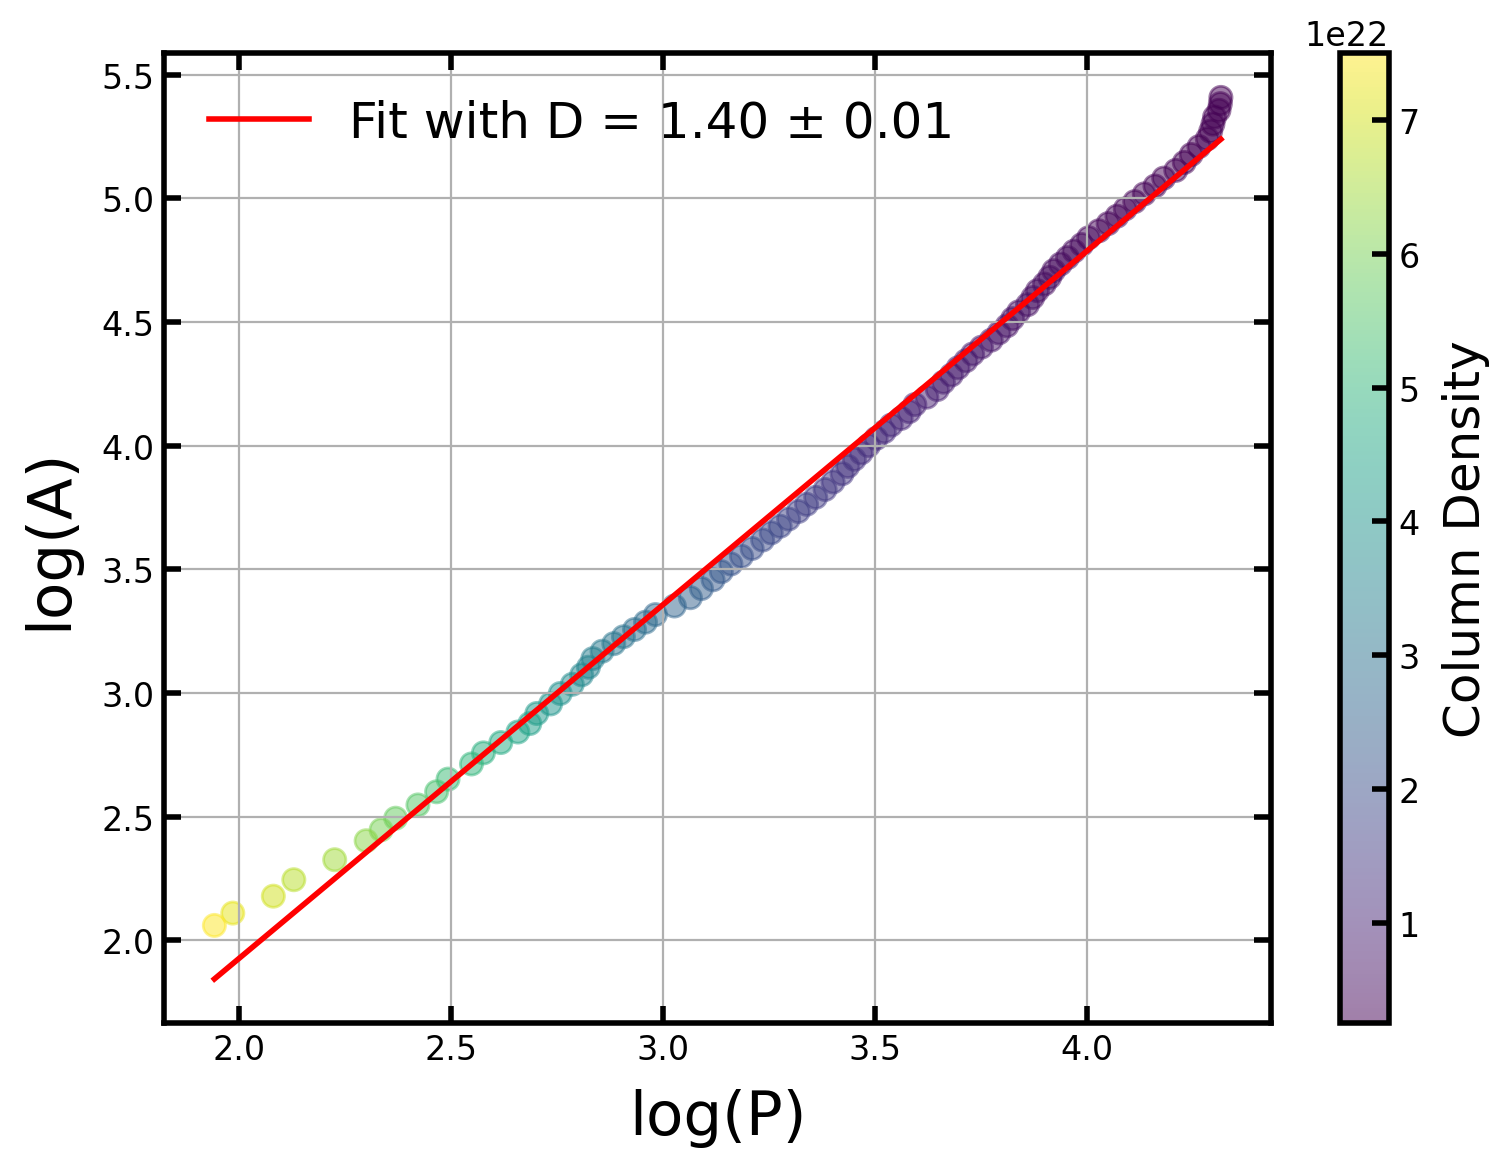

In [10]:
from scipy.stats import linregress

# global fractal dimension (Orion A)

region_name = "Orion B"

# range Orion B
threshold_min = 2.5e21
threshold_max = 7.5e22

# Minkowski
results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

log_perimeters = np.log10(np.array(results_OB["perimeters"]))
log_areas = np.log10(np.array(results_OB["areas"]))

# Perform linear regression
coefficients = np.polyfit(log_perimeters, log_areas, 1)
slope, intercept = coefficients

# Calculate correlation coefficient between log_perimeters and log_areas
corr_coef = np.corrcoef(log_perimeters, log_areas)[0, 1]
print(f"Correlation coefficient: {corr_coef:.4f}")

# Estimate fit uncertainty (standard error of the slope)
reg = linregress(log_perimeters, log_areas)
slope_err = reg.stderr
print(f"Slope uncertainty (standard error): {slope_err:.4f}")
print(f"Fractal dimension D = {2/slope:.2f} ± {2 * slope_err / slope**2:.2f}")

plt.figure(figsize=(8, 6))
# Normalize thresholds for color mapping
thresholds = results_OA["thresholds"]
norm = plt.Normalize(threshold_min, threshold_max)
cmap = plt.cm.viridis

# Scatter plot with color gradient based on thresholds
sc = plt.scatter(
    log_perimeters, log_areas,
    c=thresholds, cmap=cmap, norm=norm, alpha = 0.5
)
cbar = plt.colorbar(sc)
cbar.set_label("Column Density", fontsize=18)
plt.plot(
    log_perimeters,
    slope * log_perimeters + intercept,
    label=f"Fit with D = {2/slope:.2f} ± {2 * slope_err / slope**2:.2f}",
    color="red"
)
plt.xlabel("log(P)", fontsize=22)
plt.ylabel("log(A)", fontsize=22)
# plt.title("Log-Log Plot of Areas vs Perimeters with Linear Fit")
plt.legend(fontsize=18)
plt.grid(True)
plt.show()

2.972512859016305
Low log(P) <= 3.9: slope=1.209 ± 0.009, D=1.65 ± 0.01, corr=0.9986
High log(P) > 3.9: slope=2.064 ± 0.068, D=0.97 ± 0.03, corr=0.9748
Low log(P) <= 3.9: slope=1.209, D=1.65, corr=0.9986
High log(P) > 3.9: slope=2.064, D=0.97, corr=0.9748


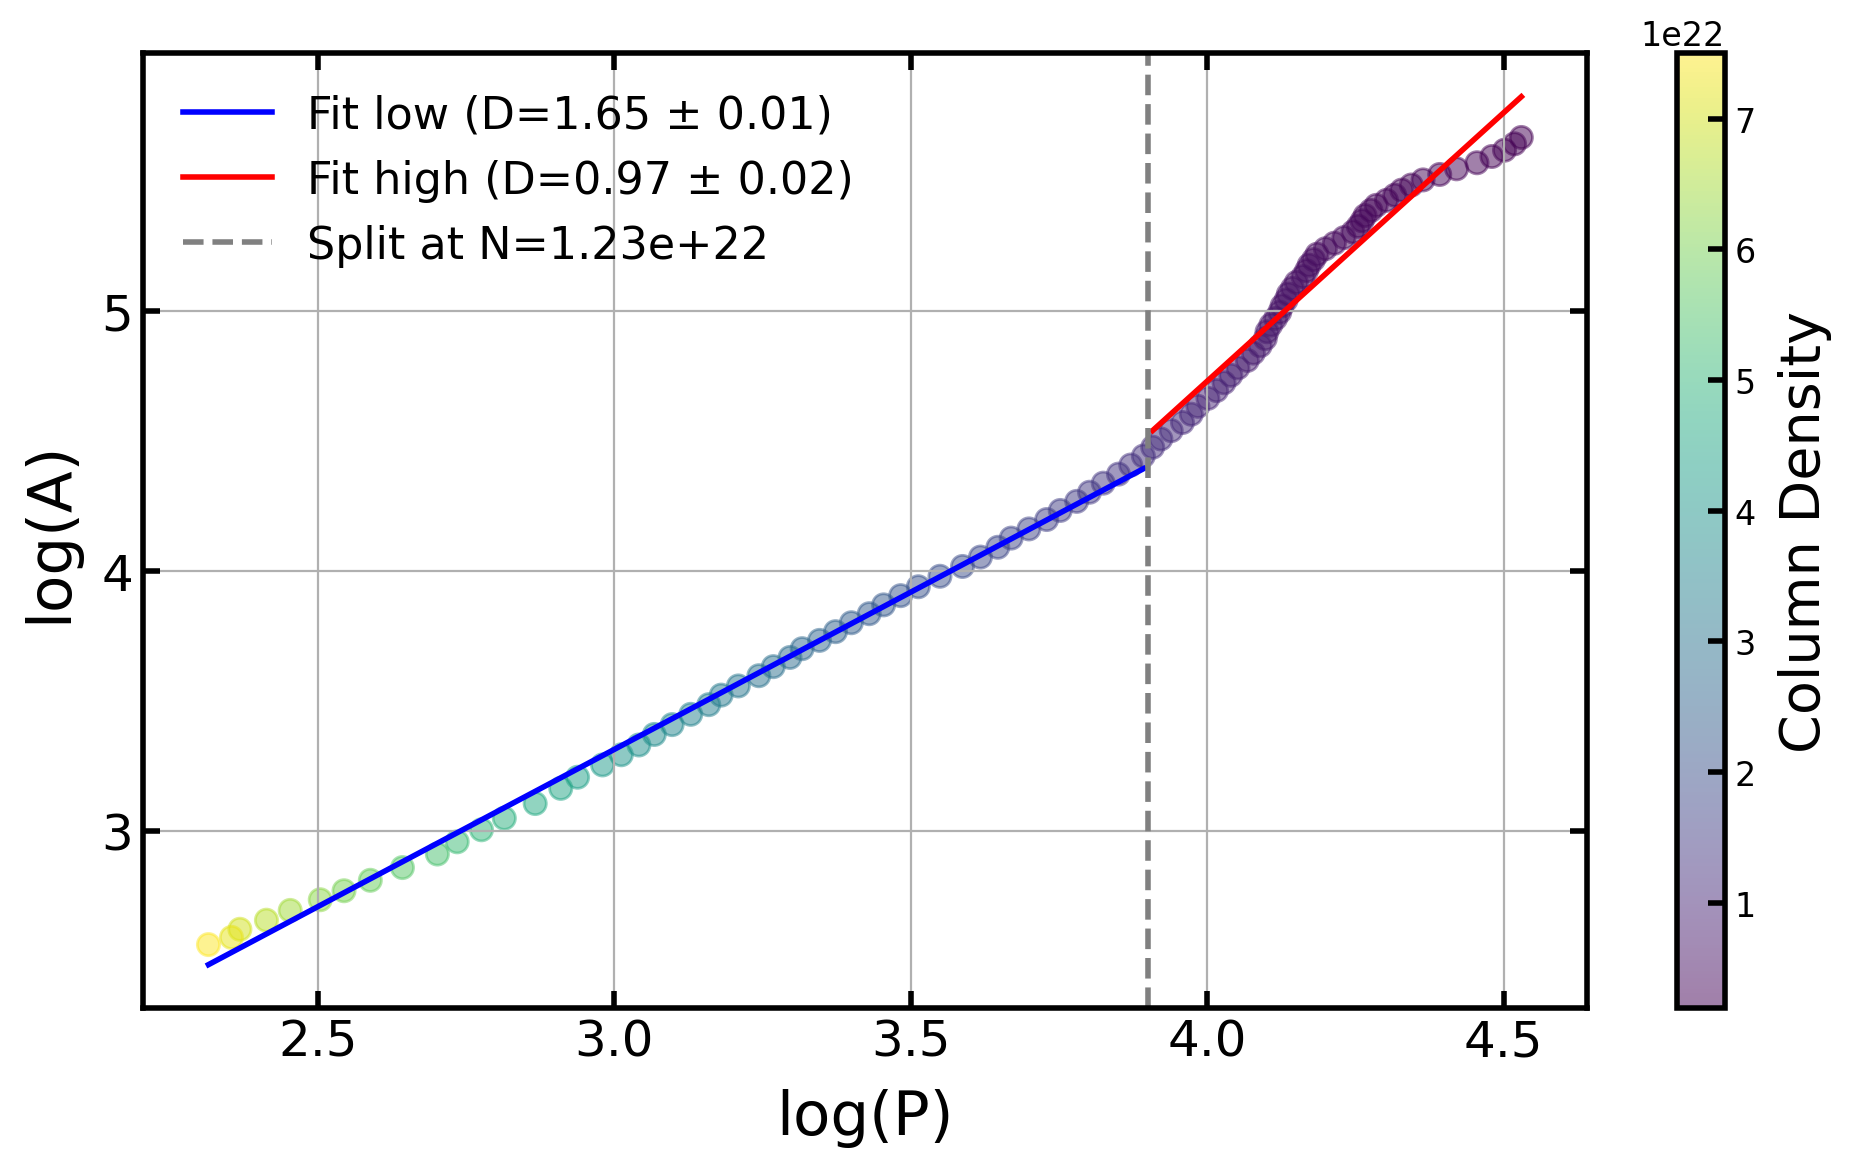

In [21]:
from scipy.stats import linregress

# global fractal dimension (Orion A, two fits)

# Orion A
region_name = "Orion A"

# overall, these work best for the whole region
threshold_min = 1.95e21
threshold_max = 7.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down
# threshold_max = 1.0e23

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

log_perimeters = np.log10(np.array(results_OA["perimeters"]))
log_areas = np.log10(np.array(results_OA["areas"]))

# Split data
split_value = 3.9
mask_low = log_perimeters <= split_value
mask_high = log_perimeters > split_value

# Fit for low log(P)
coeff_low = np.polyfit(log_perimeters[mask_low], log_areas[mask_low], 1)
slope_low, intercept_low = coeff_low
reg_low = linregress(log_perimeters[mask_low], log_areas[mask_low])
corr_coef_low = np.corrcoef(log_perimeters[mask_low], log_areas[mask_low])[0, 1]
slope_err_low = reg_low.stderr
D_low = 2 / slope_low
D_err_low = 2 * slope_err_low / slope_low**2

# Fit for high log(P)
coeff_high = np.polyfit(log_perimeters[mask_high], log_areas[mask_high], 1)
slope_high, intercept_high = coeff_high
reg_high = linregress(log_perimeters[mask_high], log_areas[mask_high])
corr_coef_high = np.corrcoef(log_perimeters[mask_high], log_areas[mask_high])[0, 1]
slope_err_high = reg_high.stderr
D_high = 2 / slope_high
D_err_high = 2 * slope_err_high / slope_high**2

print(f"Low log(P) <= {split_value}: slope={slope_low:.3f} ± {slope_err_low:.3f}, D={D_low:.2f} ± {D_err_low:.2f}, corr={corr_coef_low:.4f}")
print(f"High log(P) > {split_value}: slope={slope_high:.3f} ± {slope_err_high:.3f}, D={D_high:.2f} ± {D_err_high:.2f}, corr={corr_coef_high:.4f}")

print(f"Low log(P) <= {split_value}: slope={slope_low:.3f}, D={2/slope_low:.2f}, corr={corr_coef_low:.4f}")
print(f"High log(P) > {split_value}: slope={slope_high:.3f}, D={2/slope_high:.2f}, corr={corr_coef_high:.4f}")

plt.figure(figsize=(10, 6))
thresholds = results_OA["thresholds"]
norm = plt.Normalize(threshold_min, threshold_max)
cmap = plt.cm.viridis

sc = plt.scatter(
    log_perimeters, log_areas,
    c=thresholds, cmap=cmap, norm=norm, alpha=0.5
)

# Plot both fits
x_low = np.linspace(log_perimeters[mask_low].min(), log_perimeters[mask_low].max(), 100)
x_high = np.linspace(log_perimeters[mask_high].min(), log_perimeters[mask_high].max(), 100)
plt.plot(x_low, slope_low * x_low + intercept_low, color="blue", label=f"Fit low (D={2/slope_low:.2f} ± 0.01)")
plt.plot(x_high, slope_high * x_high + intercept_high, color="red", label=f"Fit high (D={2/slope_high:.2f} ± 0.02)")

# Draw a vertical line at the split, labeled with the corresponding threshold value
split_idx = np.abs(log_perimeters - split_value).argmin()
split_threshold = thresholds[split_idx]
plt.axvline(split_value, color='gray', linestyle='--', label=f"Split at N={split_threshold:.2e}")

cbar = plt.colorbar(sc)
cbar.set_label("Column Density", fontsize=20)

plt.xlabel("log(P)", fontsize=22)
plt.ylabel("log(A)", fontsize=22)
plt.legend(fontsize=16)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.locator_params(axis='x', nbins=5)
plt.locator_params(axis='y', nbins=5)

plt.grid(True)
plt.show()

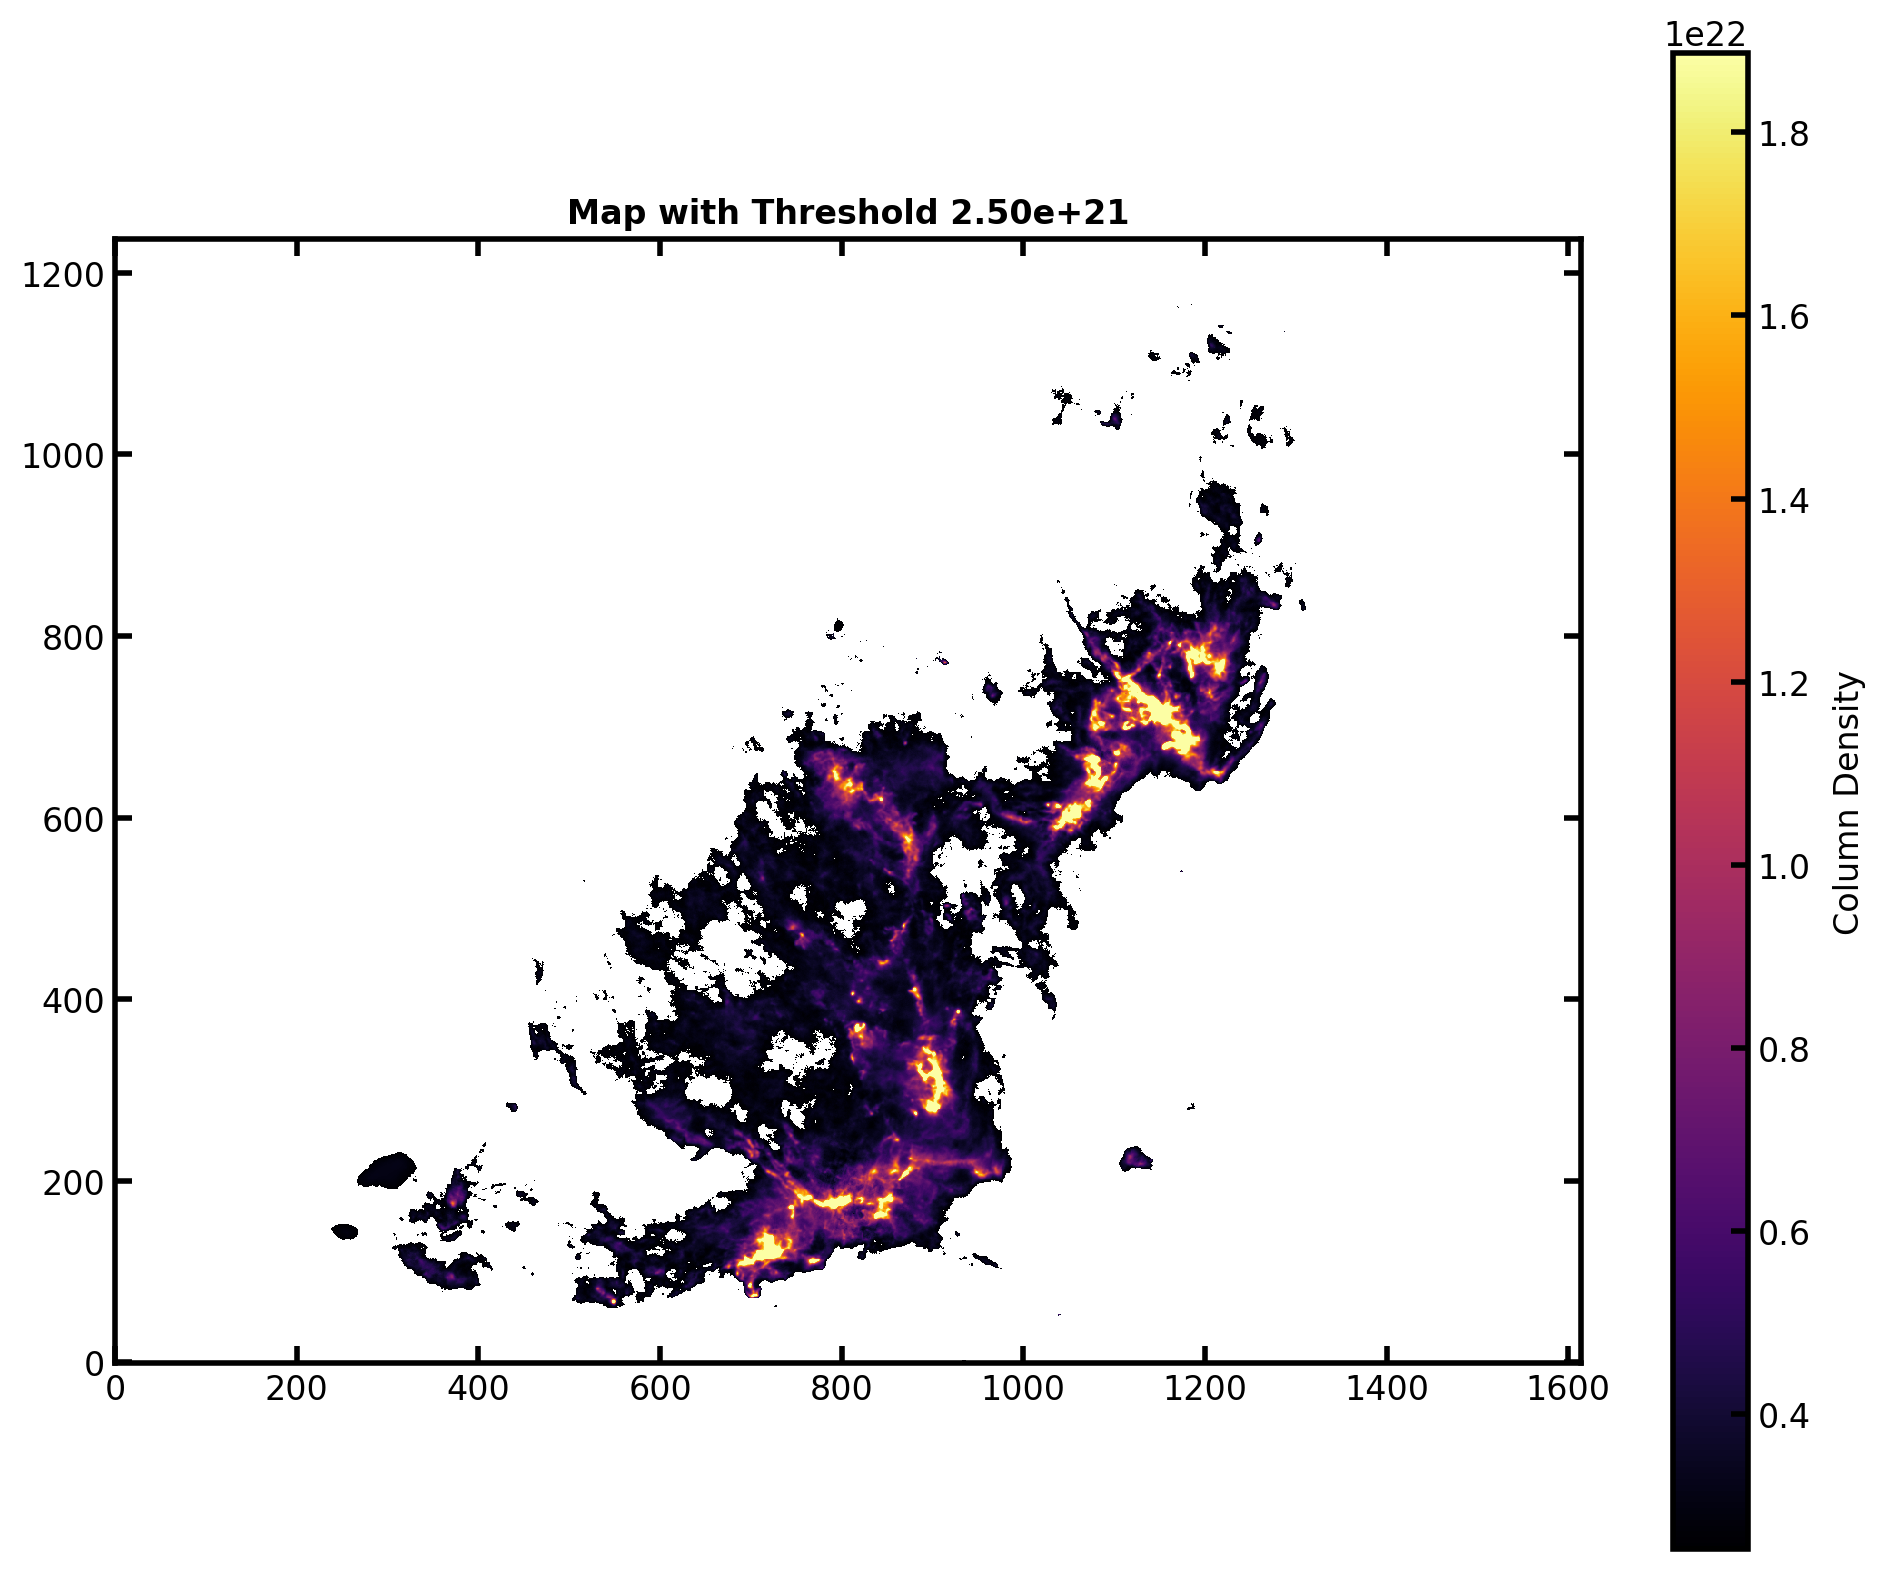

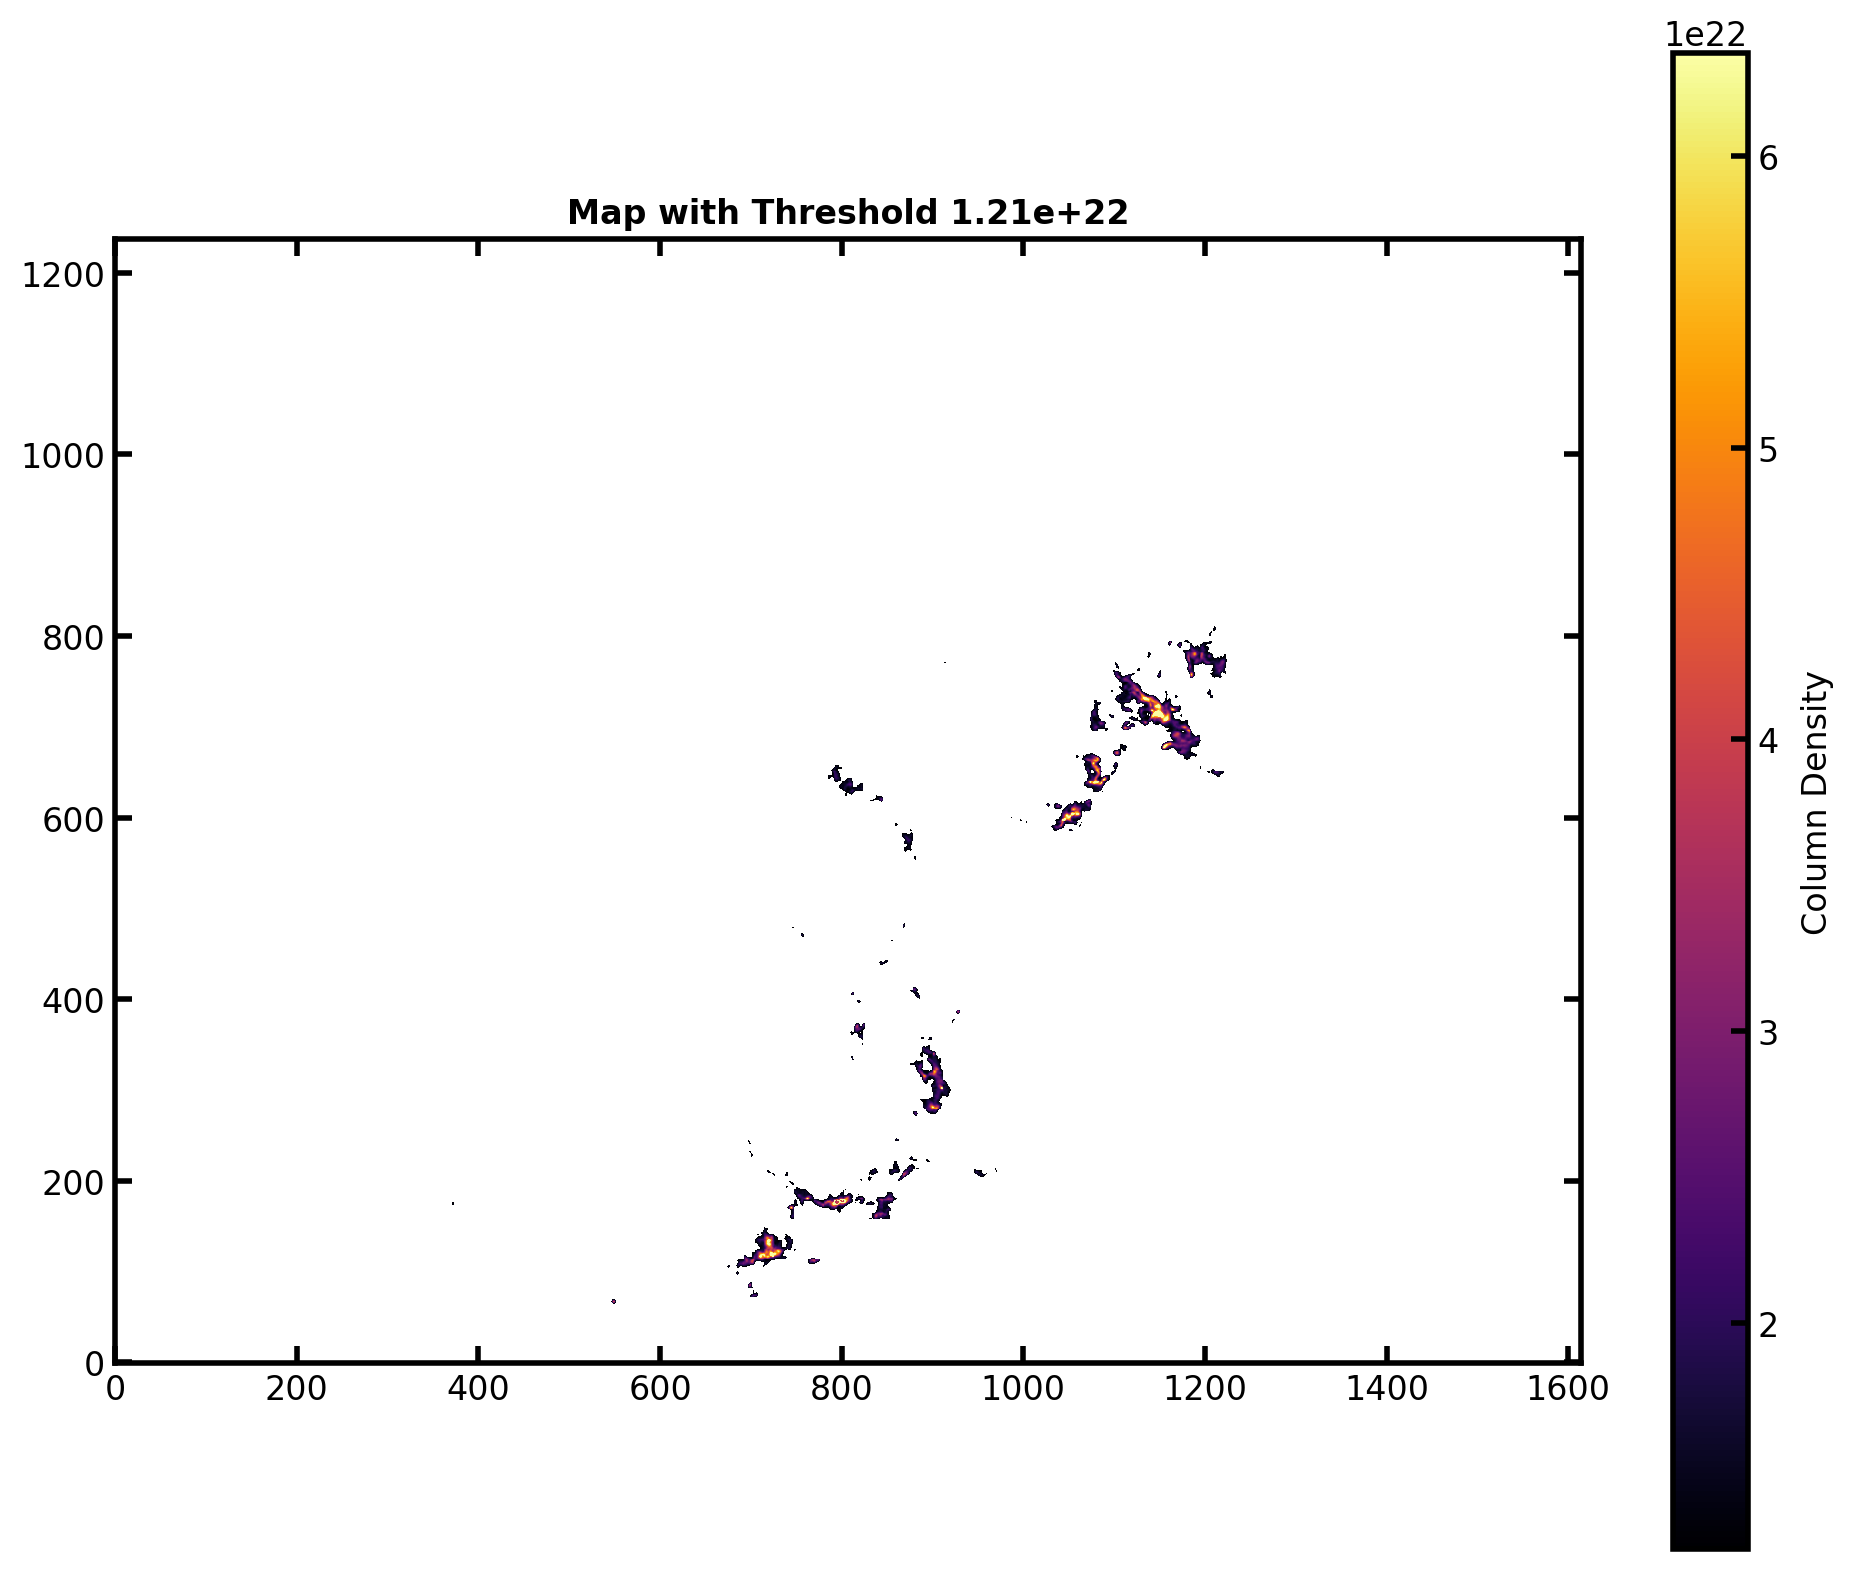

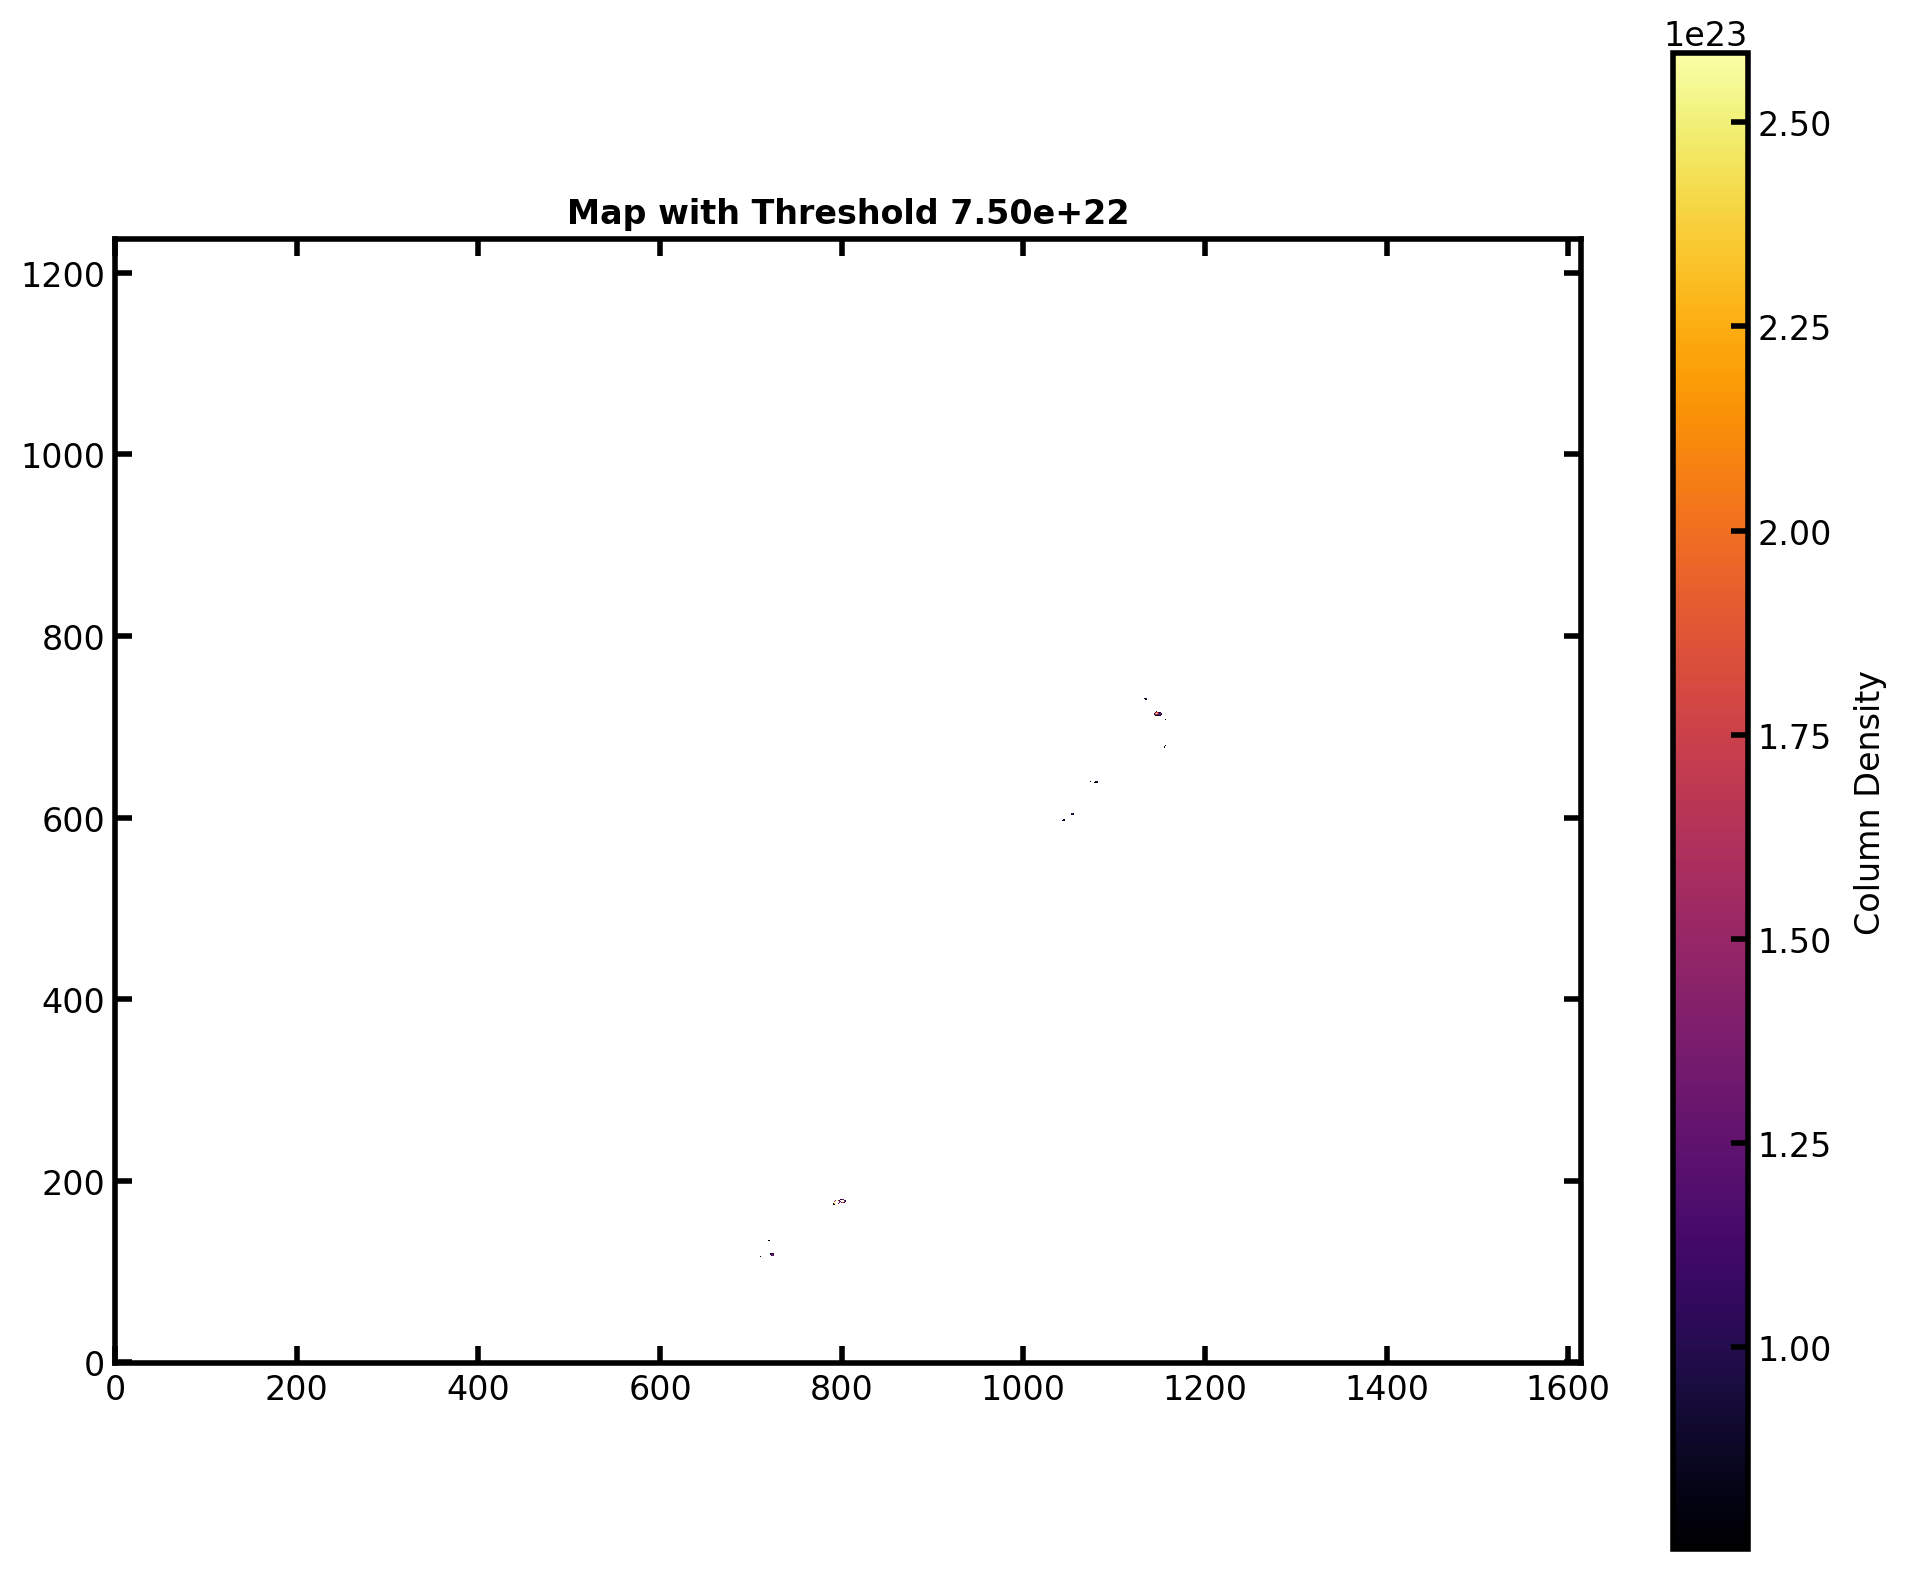

In [9]:
show_regions_with_sections(N_H2_OB, n_regions= 0, thresholds=[2.5e21, 1.21e22, 7.5e22])

# **Euler Characteristic**

In [7]:
from GRF import generate_gaussian_random_field

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 7.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down

thresholds_OA = np.linspace(threshold_min, threshold_max, 100)

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA)
results_OB = standard_minkowski_functionals(N_H2_OB)

# GRF, _ = generate_gaussian_random_field(512, a=-2)

# thresholds_GRF = np.linspace(np.min(GRF), np.max(GRF), 100)

# results_GRF = standard_minkowski_functionals(GRF)

0.682585707254066
1.283390763661845


C:\Users\User\AppData\Local\Temp\ipykernel_6420\2425883042.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


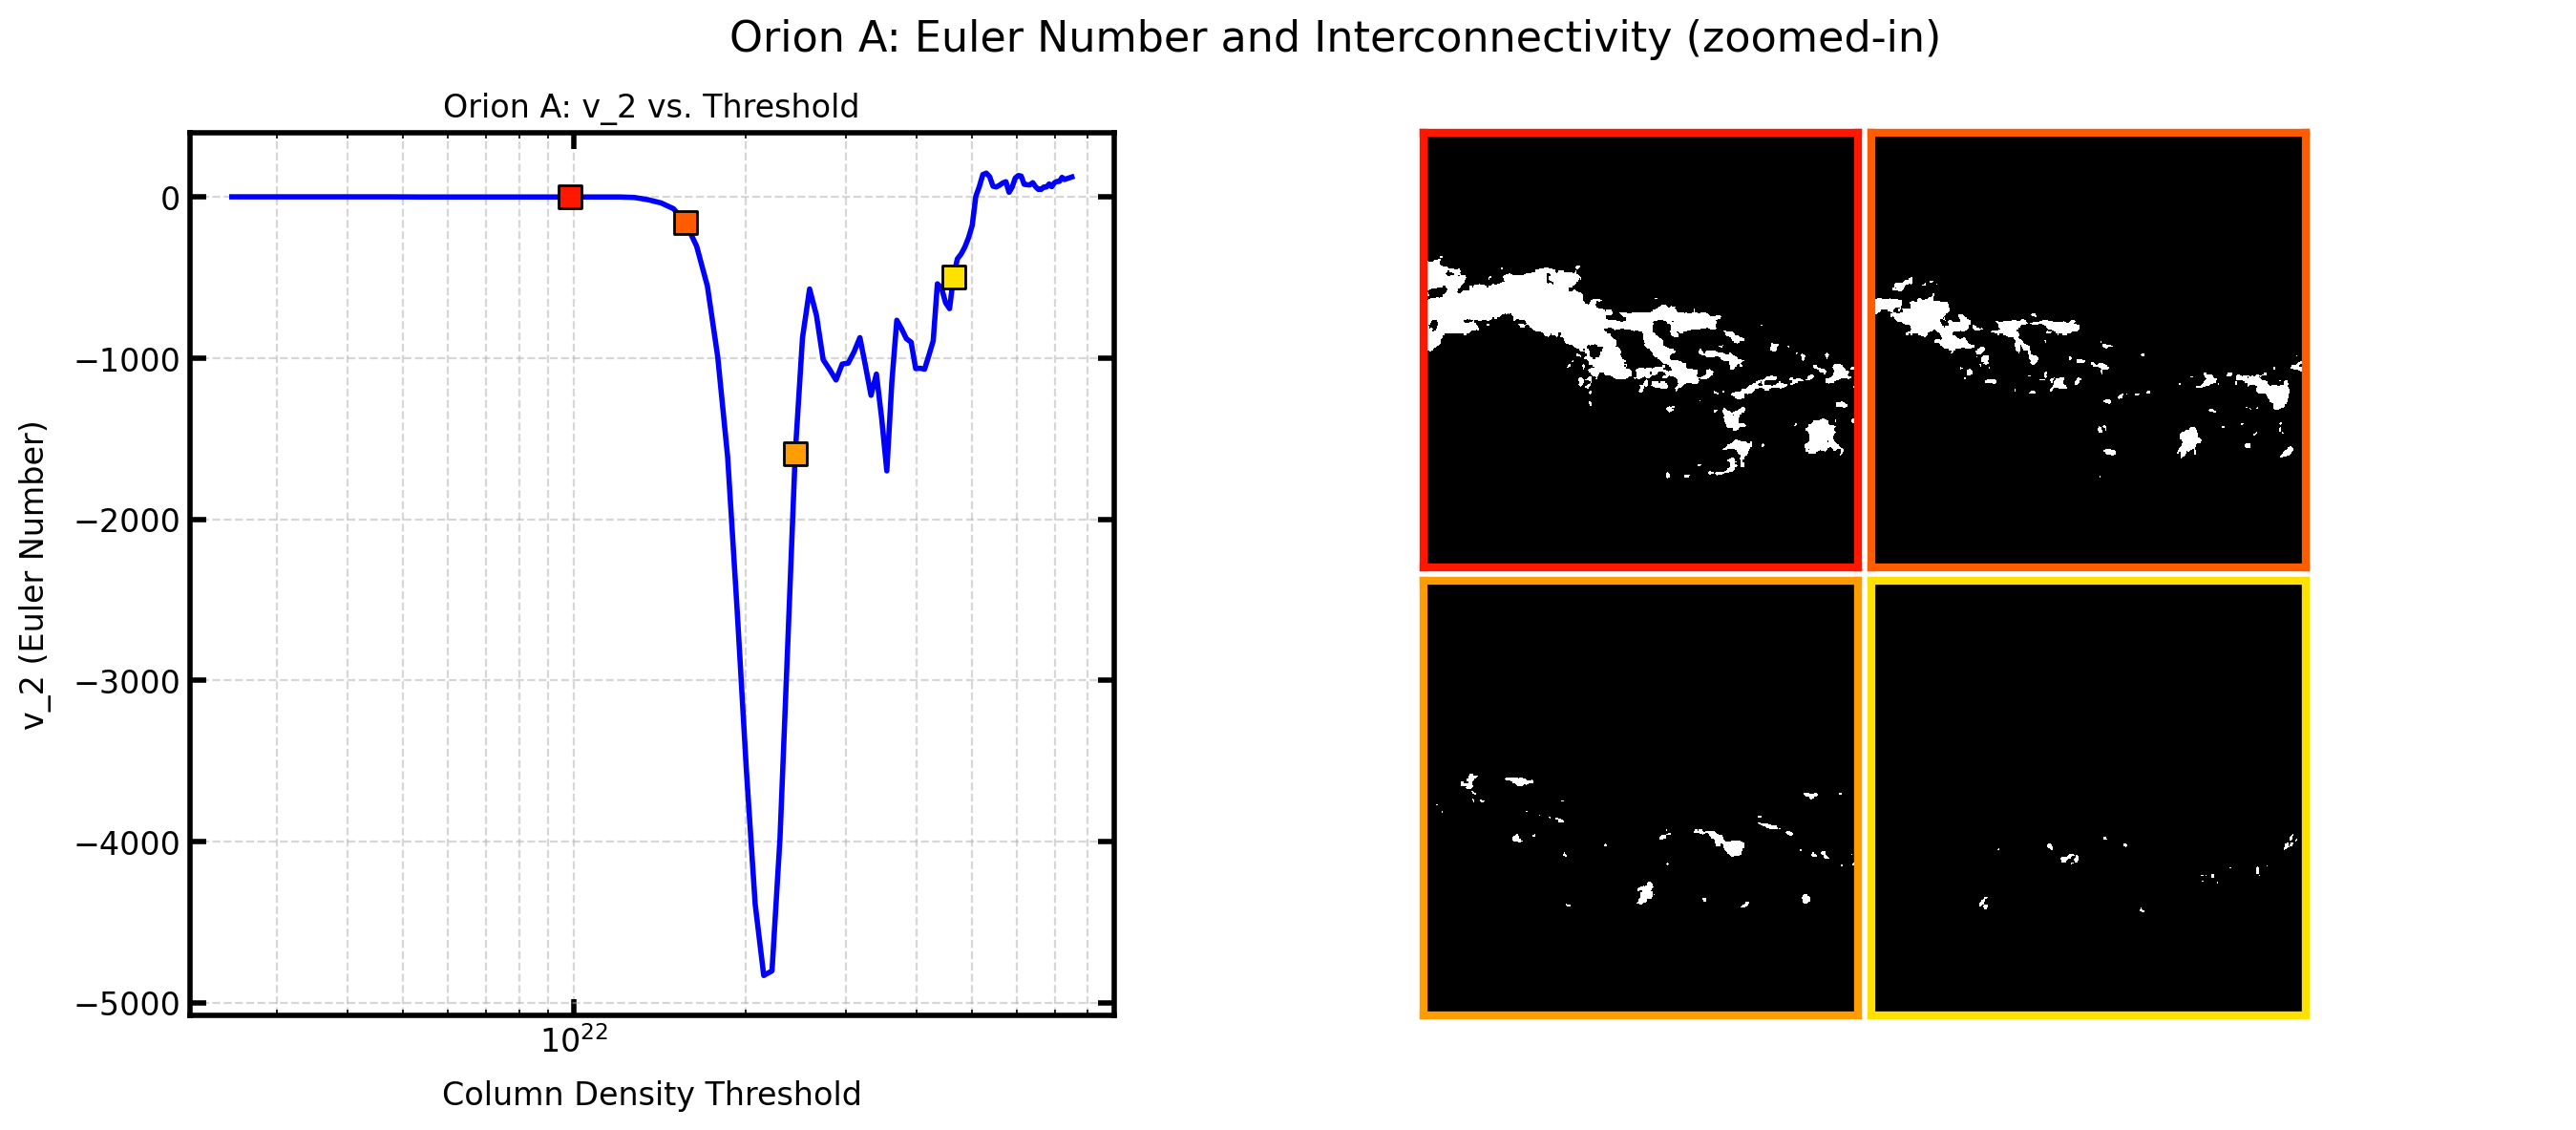

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import ImageGrid

def slice_around_mask_center(mask, zoom_pixels=200):
    """
    Returns a slice around the center of the mask region with a fixed zoom size.
    
    Parameters:
        mask (2D array): Binary mask (e.g., structure >= threshold)
        zoom_pixels (int): Half-width/height of the zoom box in pixels
        
    Returns:
        y_slice, x_slice: slice objects to index the region
    """
    y, x = np.where(mask)
    if len(x) == 0 or len(y) == 0:
        # fallback: center of the full image
        center_y, center_x = mask.shape[0] // 2, mask.shape[1] // 2
    else:
        # center of the structure
        center_y = int(np.mean(y))
        center_x = int(np.mean(x))

    y_min = max(center_y - zoom_pixels, 0)
    y_max = min(center_y + zoom_pixels, mask.shape[0])
    x_min = max(center_x - zoom_pixels, 0)
    x_max = min(center_x + zoom_pixels, mask.shape[1])

    return slice(y_min, y_max), slice(x_min, x_max)


def plot_euler_and_structures(data, thresholds, euler_results, title_prefix, example_threshold_indices, cmap='gray'):
    fig = plt.figure(figsize=(16, 6))

    # Create a gridspec to place the main plot and image grid
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5], wspace=0.05)

    # Left: Euler number vs threshold
    ax_curve = fig.add_subplot(gs[0])
    ax_curve.plot(thresholds, euler_results, color='blue')
    ax_curve.set_xscale("log")
    ax_curve.set_xlabel("Column Density Threshold")
    ax_curve.set_ylabel("v_2 (Euler Number)")
    ax_curve.set_title(f"{title_prefix}: v_2 vs. Threshold")
    ax_curve.grid(True, which="both", ls="--", alpha=0.5)

    # Mark the selected thresholds
    colors = plt.cm.hot(np.linspace(0.4, 0.7, len(example_threshold_indices)))
    for idx, color in zip(example_threshold_indices, colors):
        ax_curve.scatter(thresholds[idx], euler_results[idx], color=color, s=70, edgecolor='black', zorder=5, marker="s")

    # Right: 2x2 grid of structure examples
    ax_grid_container = fig.add_subplot(gs[1])
    ax_grid_container.axis('off')  # Remove container axis

    grid = ImageGrid(fig, gs[1], nrows_ncols=(2, 2), axes_pad=0.07, share_all=True, cbar_mode=None)

    for ax, idx, color in zip(grid, example_threshold_indices, colors):
        mask = data >= thresholds[idx]

        y_slice, x_slice = slice_around_mask_center(mask)

        ax.imshow(mask[y_slice, x_slice], cmap=cmap, origin='lower')
        # ax.imshow(mask, origin='lower', cmap='inferno')
        # ax.set_title(f"Threshold = {thresholds[idx]:.2e}\nEuler = {euler_results[idx]}")
        # Set border color
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.suptitle(f"{title_prefix}: Euler Number and Interconnectivity (zoomed-in)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

example_indices_OA = [10, 18, 30, 60]
plot_euler_and_structures(N_H2_OA, thresholds_OA, results_OA["euler_chars"], "Orion A", example_indices_OA)
